In [56]:
import kaggle
from distributed.utils import palette

kaggle.api.authenticate()
kaggle.api.dataset_download_files('andrewmvd/okcupid-profiles', path='.', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/okcupid-profiles


# OkCupid - Data Science Project

Leave Introduction for the end, right now I don't really know what i am focusing on, first I want to analyze the data.
Ideas that I find interesting for the objective:
1. Sociological Approach: Education level vs Religion (How does reported education influence people's beliefs.)
2. The NLP problem: Sentiment vs Success (Do people with more energetic/positive language in their self summary have different traits (Like higher income or specific jobs))
3. Classification problem: Predict Education level based on their essays (length, vocabulary and income)

### Setup for Objectives

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

In [88]:
#Turn our csv into a dataframe
profiles = pd.read_csv('../Dataset/okcupid_profiles.csv')
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   sex          59946 non-null  object 
 3   orientation  59946 non-null  object 
 4   body_type    54650 non-null  object 
 5   diet         35551 non-null  object 
 6   drinks       56961 non-null  object 
 7   drugs        45866 non-null  object 
 8   education    53318 non-null  object 
 9   ethnicity    54266 non-null  object 
 10  height       59943 non-null  float64
 11  income       59946 non-null  int64  
 12  job          51748 non-null  object 
 13  last_online  59946 non-null  object 
 14  location     59946 non-null  object 
 15  offspring    24385 non-null  object 
 16  pets         40025 non-null  object 
 17  religion     39720 non-null  object 
 18  sign         48890 non-null  object 
 19  smok

## Sociological Approach: Education level vs Religion
I wanted to start by modeling something that I personally find interesting. And see what I find


### Setting clear buckets for the education level

In [89]:
#Take a look at what values we have to see how we classify the data
# print(profiles['education'].unique())
#The function to separate into distinct buckets
def segment_education(status):
    # Handle NaNs
    if pd.isna(status):
        return 'not specified'
    status = status.lower()
    # 1.Noise Category
    if 'space camp' in status:
        return 'space camp'
    # 2. Dropped Out
    if 'dropped out' in status:
        return 'dropped out'
    # 3. Post-Graduate
    if any(edu in status for edu in ['masters', 'ph.d', 'law school', 'med school']):
        return 'post-grad'
    # 4. Undergraduate
    if any(edu in status for edu in ['college', 'university', 'two-year college']):
        return 'undergrad'
    # 5. High School
    if 'high school' in status:
        return 'high school'

    return 'other'

profiles['edu_cleaned'] = profiles['education'].apply(segment_education)

### Setting clear buckets for religion

In [94]:
#print(profiles['religion'].unique())
# All strings follow the same pattern: They first state their religion and then how serious they take it
def clean_religion(entry):
    if pd.isna(entry):
        return 'not specified'
    entry = entry.lower()
    religion = entry.split(' and ')[0].split(' but ')[0]
    return religion.strip()

profiles['religion_cleaned'] = profiles['religion'].apply(clean_religion)

def extract_seriousness(entry):
    if pd.isna(entry):
        return 'not specified'

    entry = entry.lower()
    if 'very serious' in entry:
        return 'high' # Or 3
    elif 'somewhat serious' in entry:
        return 'medium' # Or 2
    elif 'not too serious' in entry:
        return 'low' # Or 1
    elif 'laughing about it' in entry:
        return 'minimal/ironic' # Or 0

    return 'neutral' # For entries like just "atheism" or "christianity"

profiles['religion_seriousness'] = profiles['religion'].apply(extract_seriousness)
#print(profiles['religion_seriousness'].unique())


['high' 'low' 'not specified' 'neutral' 'minimal/ironic' 'medium']


### Plots after some data cleaning

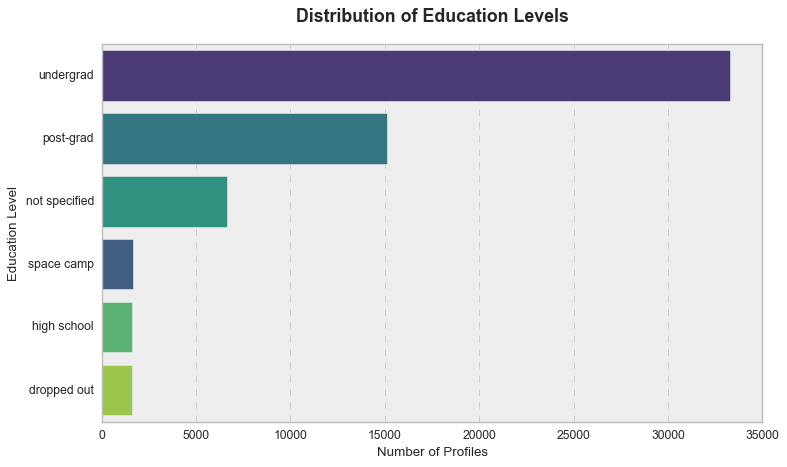

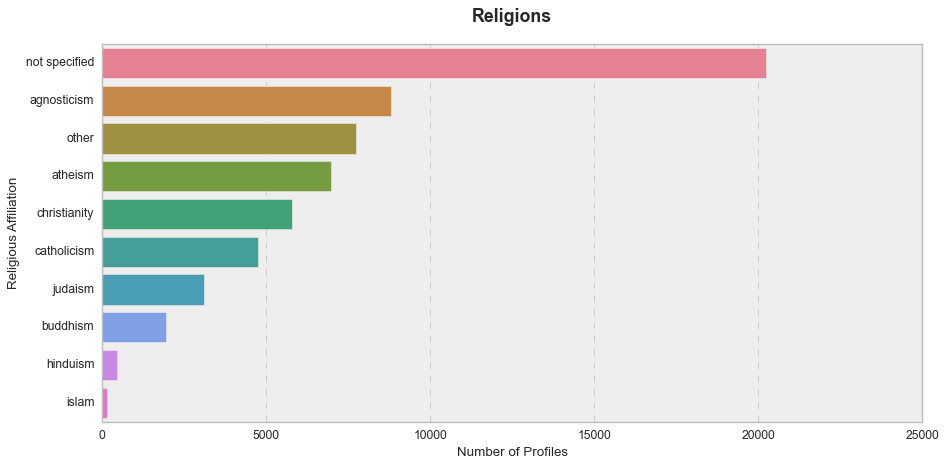

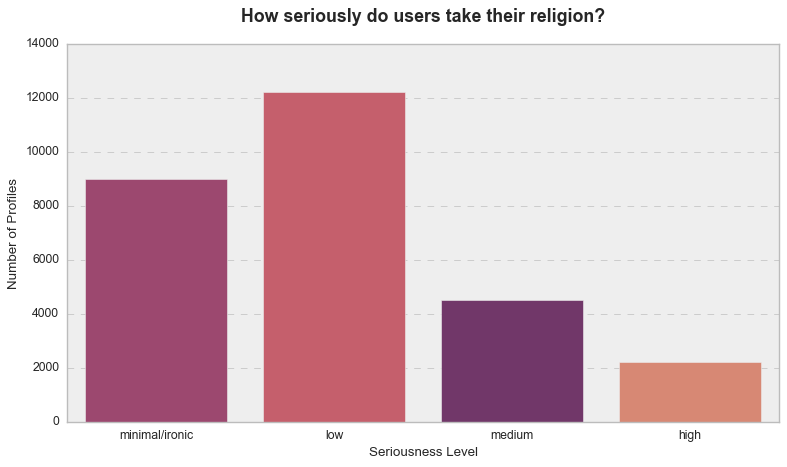

In [96]:
# Style of figures
plt.style.use('bmh')
sns.set_palette('viridis')

# 1 Distribution of education levels
plt.figure(figsize=(10, 6))
order = profiles['edu_cleaned'].value_counts().index
sns.countplot(data=profiles, y='edu_cleaned', hue='edu_cleaned', order= order)

plt.title('Distribution of Education Levels', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Number of Profiles', fontsize=12)
plt.ylabel('Education Level', fontsize=12)

plt.tight_layout()
plt.show()
#2 Religious distribution levels
plt.figure(figsize=(12, 6))
religion_counts = profiles['religion_cleaned'].value_counts()
sns.barplot(x=religion_counts.values, y=religion_counts.index, hue=religion_counts.index)
plt.title('Religions', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Profiles', fontsize=12)
plt.ylabel('Religious Affiliation', fontsize=12)
plt.tight_layout()
plt.show()

#3 How religious are the people
serious_df = profiles[(profiles['religion_seriousness'] != 'not specified') & (profiles['religion_seriousness'] != 'neutral')]
#print(serious_df.head)
plt.figure(figsize=(10, 6))

seriousness_order = ['minimal/ironic', 'low', 'medium', 'high']

sns.countplot(data=serious_df, x='religion_seriousness', hue='religion_seriousness', order=seriousness_order, palette='flare')

plt.title('How seriously do users take their religion?', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Seriousness Level', fontsize=12)
plt.ylabel('Number of Profiles', fontsize=12)
plt.tight_layout()
plt.show()

### Exploring the Education vs Religion problem


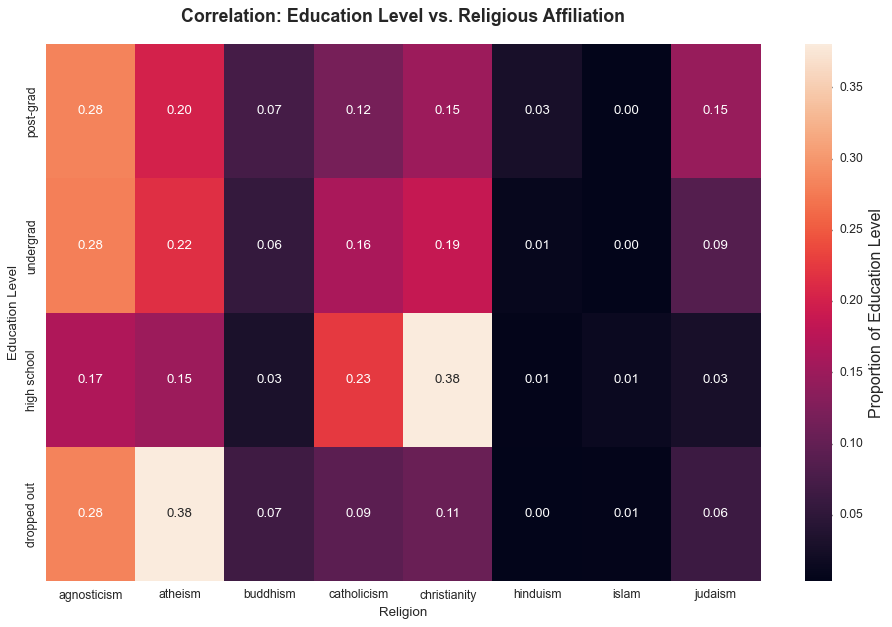

Chi-Square Statistic: 1086.9981638034687
P-value: 7.92581324711559e-217


In [92]:

noise_rel = ['not specified', 'other']
edu_order = ['post-grad', 'undergrad', 'high school', 'dropped out']

df_clean = profiles[(profiles['edu_cleaned'].isin(edu_order)) & (~profiles['religion_cleaned'].isin(noise_rel))].copy()


# 2. Create the Contingency Table (Cross-tabulation)
# 'normalize="index"' scales the rows so they add up to 100%
cross_tab = pd.crosstab(df_clean['edu_cleaned'], df_clean['religion_cleaned'], normalize='index')
cross_tab_ordered = cross_tab.reindex(index=edu_order)
# 3. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab_ordered, annot=True, fmt=".2f", cmap="rocket", cbar_kws={'label': 'Proportion of Education Level'})

plt.title('Correlation: Education Level vs. Religious Affiliation', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Religion', fontsize=12)
plt.ylabel('Education Level', fontsize=12)
plt.tight_layout()
plt.show()

# Run the test on raw counts (not normalized)
raw_ctab = pd.crosstab(df_clean['edu_cleaned'], df_clean['religion_cleaned'])
chi2, p, dof, expected = chi2_contingency(raw_ctab)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-value: {p}")

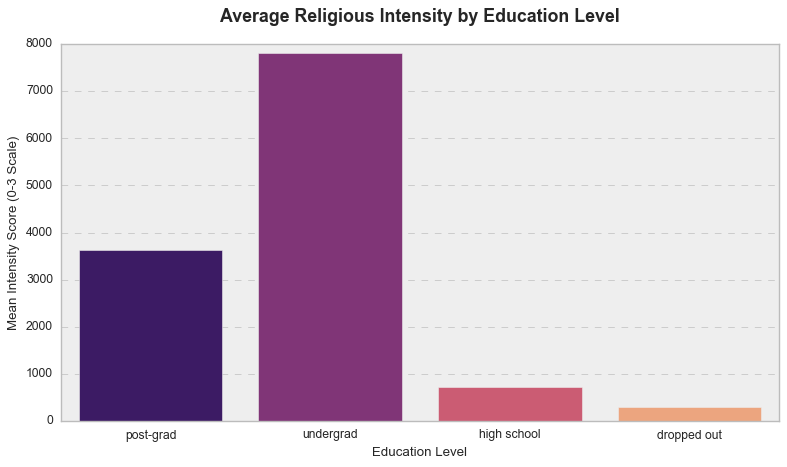

In [99]:
serious_score = {'minimal/ironic':0, 'low':1, 'medium':2, 'high':3}
religions = ['buddhism', 'catholicism', 'christianity', 'hinduism', 'islam', 'judaism']

df_intensity = profiles[(profiles['edu_cleaned'].isin(edu_order)) & (profiles['religion_cleaned'].isin(religions)) &
                        (profiles['religion_seriousness'].isin(serious_score.keys()))].copy()
#print(df_intensity['religion_seriousness'].unique())

df_intensity['intensity_score'] = df_intensity['religion_seriousness'].map(serious_score)

mean_scores = df_intensity.groupby('edu_cleaned')['intensity_score'].sum().reindex(edu_order)

plt.figure(figsize=(10, 6))
sns.barplot(x=mean_scores.index, y=mean_scores.values, hue=mean_scores.index, palette='magma')

plt.title('Average Religious Intensity by Education Level', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Mean Intensity Score (0-3 Scale)', fontsize=12)
plt.xlabel('Education Level', fontsize=12)


plt.tight_layout()
plt.show()

